
# Soma1 (latest version from Max) Tapenade Adjoint Analysis: Serial Run

Enter your grid/tile parameters once, and the rest of the notebook computes shapes, reads the manual I/O outputs, stitches tiles, removes halos, and plots.


In [1]:
from pathlib import Path
import numpy as np
import xarray as xr
import xmitgcm
import matplotlib.pyplot as plt

import warnings; warnings.filterwarnings("ignore")

## User Parameters and Paths

In [2]:
# --- USER PARAMETERS ---
# Enter your grid parameters here (integers)
sNx = 62   # interior x-size per tile
sNy = 62   # interior y-size per tile
OLx = 4    # halo size in x
OLy = 4    # halo size in y
nSx = 1    # number of tiles in x
nSy = 1    # number of tiles in y
Nr = 31    # number of vertical levels

# analyze a sample run directory
run_dir_srl_30d = "/scratch2/tshahriar/v4_soma_tapAdj_runs/v4StP_srl_no-kpp-GM_30d_run6869"

# --- FILES to Load ---
thetab_path = Path(run_dir_srl_30d) / 'thetab_v4_soma.data'
saltb_path  = Path(run_dir_srl_30d) / 'saltb_v4_soma.data'
# hfacc_path  = Path(run_dir_srl_30d) / 'hFacC_v4_soma.data'
# theta_path  = Path(run_dir_srl_30d) / 'theta_v4_soma.data'
# salt_path   = Path(run_dir_srl_30d) / 'salt_v4_soma.data'

## Utilities

In [3]:
# --- DERIVED SIZES ---
i_with_halo = sNx + 2*OLx
j_with_halo = sNy + 2*OLy

shape_with_halo = (nSy, nSx, Nr, j_with_halo, i_with_halo)  # (bj, bi, k, j, i)
shape_no_halo   = (nSy, nSx, Nr, sNy, sNx)
global_shape_3d = (Nr, sNy*nSy, sNx*nSx)

print("shape_with_halo:", shape_with_halo)
print("shape_no_halo  :", shape_no_halo)
print("global 3D shape:", global_shape_3d)

shape_with_halo: (1, 1, 31, 70, 70)
shape_no_halo  : (1, 1, 31, 62, 62)
global 3D shape: (31, 62, 62)


In [4]:
# --- UTILITIES ---
def load_reshaped(path, shape_with_halo):
    """Load a formatted-text file (one value per line) and reshape to (nSy,nSx,Nr,jH,iH)."""
    arr = np.loadtxt(path)
    expected = np.prod(shape_with_halo, dtype=int)
    if arr.size != expected:
        raise ValueError(f"{path} has {arr.size} values but expected {expected} for shape {shape_with_halo}")
    return arr.reshape(shape_with_halo)

def drop_halo(arr, OLy, OLx):
    """Drop the halo in (nSy,nSx,Nr,jH,iH) -> (nSy,nSx,Nr,sNy,sNx)."""
    return arr[:, :, :, OLy:-OLy, OLx:-OLx]

def stitch_tiles_3d(field_nohalo):
    """
    Stitch all tiles for ALL vertical levels.
    Input : field_nohalo shape (nSy, nSx, Nr, sNy, sNx)
    Output: global_3d    shape (Nr, sNy*nSy, sNx*nSx)
    """
    nSy_, nSx_, Nr_, sNy_, sNx_ = field_nohalo.shape
    out = np.zeros((Nr_, sNy_*nSy_, sNx_*nSx_), dtype=field_nohalo.dtype)
    for k in range(Nr_):
        for bj in range(nSy_):
            jj0 = bj * sNy_; jj1 = jj0 + sNy_
            for bi in range(nSx_):
                ii0 = bi * sNx_; ii1 = ii0 + sNx_
                out[k, jj0:jj1, ii0:ii1] = field_nohalo[bj, bi, k, :, :]
    return out

## Loading and Processing the Data

In [5]:
# --- LOAD FILES ---
thetab = load_reshaped(thetab_path, shape_with_halo)
saltb = load_reshaped(saltb_path, shape_with_halo)
# hfacc  = load_reshaped(hfacc_path, shape_with_halo)

print("Loaded:")
print("  thetab:", thetab.shape)
print("  saltb :", saltb.shape)
# print("  hfacc :", hfacc.shape)

Loaded:
  thetab: (1, 1, 31, 70, 70)
  saltb : (1, 1, 31, 70, 70)


In [6]:
# plt.pcolormesh(thetab[0,0,0])

In [7]:
thetab_nohalo = drop_halo(thetab, OLy, OLx)   # (nSy,nSx,Nr,sNy,sNx)
saltb_nohalo = drop_halo(saltb, OLy, OLx)
# hfacc_nohalo  = drop_halo(hfacc,  OLy, OLx)

# Stitch all tiles to global → (Nr, sNy*nSy, sNx*nSx)
thetab_globe = stitch_tiles_3d(thetab_nohalo)
saltb_globe  = stitch_tiles_3d(saltb_nohalo)
# hfacc_globe  = stitch_tiles_3d(hfacc_nohalo)

# print("Global shapes check:", "thetab_globe = ", thetab_globe.shape, "saltb_globe = ", saltb_globe.shape, "hfacc_globe = ", hfacc_globe.shape)
print("Global shapes check:", "thetab_globe = ", thetab_globe.shape, "saltb_globe = ", saltb_globe.shape)

Global shapes check: thetab_globe =  (31, 62, 62) saltb_globe =  (31, 62, 62)


In [8]:
# print("thetab_nohalo:", thetab_nohalo.shape)

In [9]:
# plt.pcolormesh(thetab_nohalo[0,0,0]) 

The command "thetab_nohalo[0,0,0]" shaved the edges of the domain a little bit

## Analyze and Plot Adjoint Sensitivity WRT Initial Temperature

In [10]:
# xmitgcm.open_mdsdataset

In [11]:
ds = xmitgcm.open_mdsdataset(run_dir_srl_30d, 
                             grid_dir=run_dir_srl_30d,
                             ref_date = '2025-01-01',
                             delta_t = 1200,
                             iters=None
                            )

In [12]:
ds.data_vars

Data variables:
    *empty*

In [13]:
# # ds
# ds.hFacC # this is the landmask and bathymetry

When you load the data using "xmitgcm.open_mdsdataset", there is no need to load "hFacC_v4_soma.data". All grid information is automatically included in the Dataset object.

In [14]:
# ds.hFacC.isel(Z=0).plot() 
# # this command also knows how to orient latitude and longitude. No need to deal with i and j indices.

In [15]:
# ds.Depth.shape, ds.Depth.dims

In [16]:
adxx_theta = thetab_globe.copy() # (31, 62, 62) # renaming the variable
adxx_theta = xr.DataArray(adxx_theta, dims=['Z', 'YC', 'XC']) # convert gradient from np to xr
ds['adxx_theta'] = adxx_theta

In [17]:
ds.data_vars

Data variables:
    adxx_theta  (Z, YC, XC) float64 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0

In [18]:
ds.adxx_theta.shape, ds.adxx_theta.dims

((31, 62, 62), ('Z', 'YC', 'XC'))

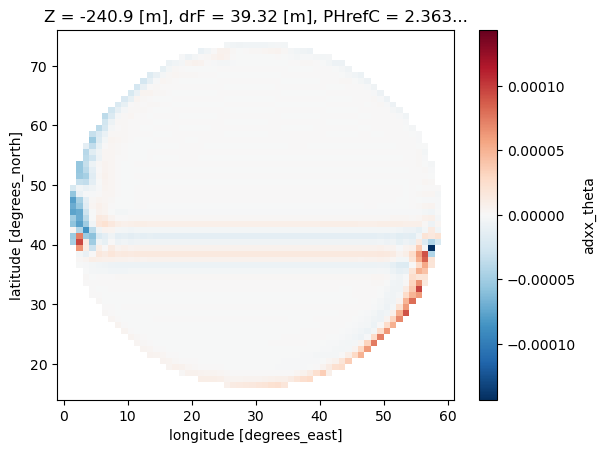

In [19]:
# plotted the sensitivity field by applying the land mask. Everything in the ocean is 1 and outside ocean is 0.
ds.adxx_theta.isel(Z=11).where(ds.hFacC.isel(Z=11)).plot() 

##--comment out the lines below to see the patterns more prominently
# vmax = 15*1e-5;vmin = -vmax
# ds.adxx_theta.isel(Z=11).where(ds.hFacC.isel(Z=11)).plot(vmin=vmin, vmax=vmax, cmap='RdBu_r')

Why do I need to pick a vertical level to see the sensitivity?

This is because the control parameter (the initial temperature) is a 3D field.

How to read the negative sensitivity?

If we decrease the initial sea surface temperature by the [magnitude], that will increase the cost or vice versa (inversely proportional relation)

How to read the positive sensitivity?

If we increase the initial sea surface temperature by the [magnitude], that will increase the cost or vice versa (proportional relation). If I incresease the initial SST by 1 degree, it will increase the cost (medidional transport at the select location) by this huge amount (in sverdrups)

### Plot `adxx_theta` Vertical Levels in a Loop

In [20]:
# nz = len(ds.Z) # number of veritical levels
# print(nz)

# for z in range(nz):
#     if z > 3: break
#     ds.adxx_theta.isel(Z=z).where(ds.hFacC.isel(Z=z)).plot()
#     plt.show()

Positive sensitivity in western boundary = warming there strengthens AMOC.

Negative sensitivity in eastern boundary = warming there weakens AMOC.

In [21]:
##--plot all the depth levels
# ds.adxx_theta.where(ds.hFacC).plot(col='Z', col_wrap=5)

### Animation of AMOC Sensitivity Across Run Lengths

This section loads the final adjoint sensitivity wrt initial temperature from multiple runs (5, 10, 15, 20, 25, 30, .... days) and animates the 2‑D field at a chosen depth. Edit the paths in the mapping below to point to your run directories.

This section stacks the adjoint sensitivity at a chosen depth across multiple run lengths
into `ds["adxx_theta_runs"]` with an extra `run_days` dimension, using `ds.XC`/`ds.YC`
for longitude/latitude coordinates. Then it renders an inline animation over `run_days`.
Requires prior cells that define: `ds`, `k_plot`, `days_to_dirs`, `adtheta_filename`,
`shape_with_halo`, `OLx`, `OLy`, and the utilities `load_reshaped`, `drop_halo`, `stitch_tiles_3d`.

In [22]:
# --- CONFIGURE RUN DIRECTORIES ---

# Map run duration (days) -> run directory path
# Fill in your actual run directories. 30-day is populated from the existing variable.
days_to_dirs = {
    5:  "/scratch2/tshahriar/v4_soma_tapAdj_runs/v4StP_srl_no-kpp-GM_5d_run6864",
    10: "/scratch2/tshahriar/v4_soma_tapAdj_runs/v4StP_srl_no-kpp-GM_10d_run6865",
    15: "/scratch2/tshahriar/v4_soma_tapAdj_runs/v4StP_srl_no-kpp-GM_15d_run6866",
    20: "/scratch2/tshahriar/v4_soma_tapAdj_runs/v4StP_srl_no-kpp-GM_20d_run6867",
    25: "/scratch2/tshahriar/v4_soma_tapAdj_runs/v4StP_srl_no-kpp-GM_25d_run6868",
    30: run_dir_srl_30d,
    60: "/scratch2/tshahriar/v4_soma_tapAdj_runs/v4StP_srl_no-kpp-GM_60d_run6870",
    90: "/scratch2/tshahriar/v4_soma_tapAdj_runs/v4StP_srl_no-kpp-GM_90d_run6871",
    120: "/scratch2/tshahriar/v4_soma_tapAdj_runs/v4StP_srl_no-kpp-GM_120d_run8003",
    150: "/scratch2/tshahriar/v4_soma_tapAdj_runs/v4StP_srl_no-kpp-GM_150d_run8004",
}

# File name used by this notebook for the adjoint temperature sensitivity
adtheta_filename = "thetab_v4_soma.data"

# Choose depth index to visualize
k_plot = 11  # 0-based index

In [23]:
# --- BUILD xr.DataArray STACK ON lon/lat ---

# Pull lon/lat and mask from ds
lon2d = ds.XC.load()
lat2d = ds.YC.load()
hfac2d = ds.hFacC.isel(Z=k_plot).load()

# Containers: frames will hold one 2-D sensitivity field per run; 
# valid_runs holds the corresponding day labels (e.g., [5,10,...])
frames = []
valid_runs = []

for days, rdir in sorted(days_to_dirs.items()):
    if not rdir:
        continue
    p = Path(rdir) / adtheta_filename
    if not p.exists():
        print(f"Skipping {days}d: missing {p}")
        continue

    arr = load_reshaped(p, shape_with_halo)          # (nSy,nSx,Nr,jH,iH)
    arr_nohalo = drop_halo(arr, OLy, OLx)            # (nSy,nSx,Nr,sNy,sNx)
    globe = stitch_tiles_3d(arr_nohalo)              # (Nr, sNy*nSy, sNx*nSx)
    field2d = globe[k_plot, :, :]                    # (YC, XC)

    # Apply mask: NaN where hFacC == 0 at this depth
    # Mask out land (and exact zeros) with NaN, so plotting ignores land and color limits aren’t skewed by zeros on land.
    field2d = np.where(hfac2d.data > 0, field2d, np.nan)

    # Wrap in DataArray with lon/lat coords
    da = xr.DataArray(
        field2d,
        dims=("YC", "XC"),
        coords={"YC": lat2d, "XC": lon2d},
        name="adxx_theta"
    )
    frames.append(da)
    valid_runs.append(days)

if not frames:
    raise RuntimeError("No valid runs found. Edit days_to_dirs.")

# Concatenate along new run dimension
# xr.concat stacks all 2-D fields along a new dimension called run_days.
# Result dims are ("run_days","YC","XC"), with coordinate values equal to your sorted run lengths.
# Attaching it to ds makes downstream plotting easy: ds["adxx_theta_runs"].sel(run_days=...) 

adxx_theta_runs = xr.concat(frames, dim=xr.DataArray(valid_runs, dims="run_days", name="run_days"))
ds["adxx_theta_runs"] = adxx_theta_runs

# Symmetric color scale across all runs
absmax = float(np.nanmax(np.abs(ds.adxx_theta_runs.data)))
#vmax = absmax
vmax=1e-04
vmin = -vmax
print(f"Stacked {len(valid_runs)} runs at Z index {k_plot}. vmin={vmin:.3e}, vmax={vmax:.3e}")
print("Run labels:", list(ds.adxx_theta_runs.run_days.values))

Stacked 10 runs at Z index 11. vmin=-1.000e-04, vmax=1.000e-04
Run labels: [5, 10, 15, 20, 25, 30, 60, 90, 120, 150]


In [24]:
# --- INTERACTIVE ANIMATION ON lon/lat (pcolormesh) ---

from matplotlib import animation
from IPython.display import HTML

run_vals = list(ds.adxx_theta_runs.run_days.values)

fig, ax = plt.subplots(figsize=(6.8, 5.4))
quad = ax.pcolormesh(
    ds["XC"], ds["YC"],
    ds["adxx_theta_runs"].sel(run_days=run_vals[0]),
    cmap="RdBu_r", vmin=vmin, vmax=vmax, shading="nearest"
)
cb = fig.colorbar(quad, ax=ax, fraction=0.046, pad=0.04, label="dJ/dθ  (cost per K)")
ttl = ax.set_title(f"AMOC sensitivity (Z index {k_plot}) — {run_vals[0]} days")
ax.set_xlabel("longitude [degrees_east]")
ax.set_ylabel("latitude [degrees_north]")

def update(i):
    quad.set_array(ds["adxx_theta_runs"].sel(run_days=run_vals[i]).values.ravel())
    ttl.set_text(f"AMOC sensitivity (Z index {k_plot}) — {run_vals[i]} days")
    return (quad, ttl)

anim = animation.FuncAnimation(fig, update, frames=len(run_vals), interval=1000, blit=False)
plt.close(fig)
HTML(anim.to_jshtml())

## Aside: Load a Diagnostic

In [25]:
# ds_dyndiag = xmitgcm.open_mdsdataset(run_dir_srl_30d, 
#                                      grid_dir=run_dir_srl_30d, 
#                                      prefix = ['dynDiag'],
#                                      ref_date = '2025-01-01',
#                                      delta_t=1200)

# ds_surf = xmitgcm.open_mdsdataset(run_dir_srl_30d, 
#                                   grid_dir=run_dir_srl_30d, 
#                                   prefix = ['surfDiag'],
#                                   ref_date = '2025-01-01',
#                                   delta_t=1200)

In [26]:
# ds_dyndiag

In "ds_dyndiag" and "ds_surfdiag", the time is 6 that is beacuse our frequency was 5 days and I am seeing a 5 days average here.

In [27]:
# ds_dyndiag.THETA.isel(time=0, Z=0).where(ds.hFacC[0]).plot()

In [28]:
# ds_dyndiag.THETA.isel(Z=0, YC=50, XC=20).plot()

In [29]:
# ds_dyndiag.VVEL.isel(time=0, Z=0).where(ds.hFacS.isel(Z=0)).plot()

In the above plot, we used hFacS instead of hFacC. This is because unlike theta and salt, VVEL is not a cell centered value. So we have to apply a different mask.

In [30]:
# u = ds_dyndiag.UVEL.isel(time=0, Z=0).where(ds.hFacW[0])
# v = ds_dyndiag.VVEL.isel(time=0, Z=0).where(ds.hFacS[0])
# nskip = 2
# u = u[::nskip, ::nskip]
# v = v[::nskip, ::nskip]
# plt.quiver(u, v, scale=1)

### Speed/KE

In [31]:
# u = ds_dyndiag.UVEL.isel(time=0, Z=0).where(ds.hFacW[0])
# v = ds_dyndiag.VVEL.isel(time=0, Z=0).where(ds.hFacS[0])
# s = np.sqrt(u.values**2 + v.values**2)
# plt.pcolormesh(s)
# plt.colorbar()
# plt.title('mean speed (first 5-day mean)')

### Attempt at a Transport Calculation

In [32]:
# ds.dxG

In [33]:
# ds.drF

In [34]:
# ds.Z

In [35]:
# (ds_dyndiag.VVEL * ds.dxG * ds.drF * ds.hFacS).isel(Z=slice(0, 14)).sel(YG=26).sum(('Z', 'XC')).sum().values

In [36]:
# (ds_dyndiag.VVEL * ds.dxG * ds.drF * ds.hFacS).isel(Z=slice(0, 14)).sel(YG=26).sum(('Z', 'XC')).plot()

In [37]:
# ds_surf.ETAN.plot(col='time')